# 05. What can a pathology foundation model see in the H&E?

**Author:** MD Shakhaowat Hossain, PhD Candidate, Tulane University School of Medicine · [Project website](https://hossainms.github.io/xenium-human-lung-cancer-ffpe/) · [Code](https://github.com/hossainms/xenium-human-lung-cancer-ffpe)

**Why:** this Xenium section has a matched H&E, and H&E is what pathology archives hold for millions of patients. Pathology foundation models, vision transformers pre-trained on hundreds of millions of histology tiles, turn an H&E patch into a numeric description without being told what to look for. The Xenium cell types and expression give each cell a molecular ground truth, so this notebook can test what the model actually sees: **the cell, or only its neighbourhood? Which cell types and which genes are visible in morphology, and which are not?** That decides what such models can and cannot be trusted to infer from H&E alone.

**Model:** **Phikon-v2** (Owkin; ViT-L trained with DINOv2 on about 460 million tiles from about 60,000 slides at 20x). It downloads without a Hugging Face account, so the notebook re-runs anywhere; `MODEL = "phikon"` switches to the smaller Phikon (ViT-B). Gated models (UNI, CONCH, Virchow2) need an access request and are not used here.

| Part | Content | Control |
|---|---|---|
| A | The H&E resampled onto the Xenium grid | cell centroids on nuclei |
| B | Cell-centred patches embedded at three scales | |
| C | Predict lineage and cell type from morphology | stain colour; the cell's Xenium neighbours; random vs. block split |
| D | Predict gene expression from morphology | own vs. regional expression; Moran's I |
| E | Morphology domains from H&E alone | BANKSY / CellCharter domains (notebook 04) |
| F | Export | |

## Setup: imports, model choice and run parameters

**Purpose:** load the shared `ist_analysis` modules and fix the parameters every later part depends on: the model, the sample size per cell type, the cross-validation block size and the tile size.

**Approach:** import `domains`, `he`, `morphology` (as `mo`) and `utils` (as `xu`), check the kernel, create the output folder, and set `MODEL`, `RECOMPUTE`, `N_PER_TYPE` (1,500 cells per type), `BLOCK_UM` (1 mm cross-validation blocks) and `TILE_UM` (112 µm tiles).

**Expected output:** the model description, the compute device (`mps`, `cuda` or `cpu`), and the output folder as a `~/...` path.

**Note:** Phikon and Phikon-v2 are released under Owkin's non-commercial licence. Changing `MODEL` or `N_PER_TYPE` invalidates the embedding cache (Part B stops with an error until `RECOMPUTE = True`).

In [1]:
from ist_analysis import domains as dm
from ist_analysis import he
from ist_analysis import morphology as mo
from ist_analysis import utils as xu   # paths and constants shared with the core workflow and the pipeline

xu.check_kernel()

import time
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import to_hex
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score as ari
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
OUT_DIR = xu.output_dir("he_foundation_model")

MODEL = "phikon-v2"     # or "phikon" (ViT-B, ~3x faster); see mo.MODELS
RECOMPUTE = False       # True = embed again even if the cache exists (~20 min on an Apple M3 Max GPU)
N_PER_TYPE = 1500       # cells sampled per cell type (all cells of rarer types)
BLOCK_UM = 1000         # cross-validation folds are split by 1 mm tissue blocks
TILE_UM = 112           # whole-slide tiles = the 112 um field of view
print(f"Model: {MODEL}, {mo.MODELS[MODEL]['note']}; device: {mo.default_device()}")
print(f"Outputs go to {xu.display_path(OUT_DIR)}")

Model: phikon-v2, ViT-L / DINOv2, 460M tiles from 60k slides (Owkin non-commercial licence); device: mps
Outputs go to ~/data/xenium_lung/processed/he_foundation_model


## Part A: The H&E on the Xenium grid

**Purpose:** put the H&E in Xenium coordinates, so that the patch around any Xenium cell is a simple array slice, and confirm that the alignment holds at single-cell scale.

**Approach:** the H&E was scanned separately and is rotated by about 90° relative to the Xenium image; 10x provides the affine transform between them (checked in Step 8: hematoxylin vs DAPI r = 0.60 at zero shift). `mo.aligned_he` resamples the H&E once onto the Xenium grid at two resolutions:

| Field of view | Resolution | Source | Shows |
|---|---|---|---|
| **56 µm** (224 px) | 0.25 µm/px (~40x) | H&E pyramid level 0 | the cell and its immediate neighbours |
| **112 µm** (224 px) | 0.5 µm/px (~20x, the model's training scale) | level 1 | the cell in its tissue context |

**Expected output:** the size and build time of each resampled image, the number of high-confidence cells and cell types, and two panels: the whole section with TLS1 boxed, and a 120 µm view of TLS1 with Xenium centroids coloured by lineage. Check that the centroids sit on hematoxylin-stained nuclei.

**Note:** the 0.25 µm/px image is about 1.8 GB in memory (peak use ~8 GB during the build); close other memory-heavy sessions first.

cell_56um: H&E level 0 resampled to 0.25 um/px on the Xenium grid: 43,840 x 13,472 px (30 s)
context_112um: H&E level 1 resampled to 0.5 um/px on the Xenium grid: 21,920 x 6,736 px (7 s)

139,129 high-confidence cells, 26 cell types


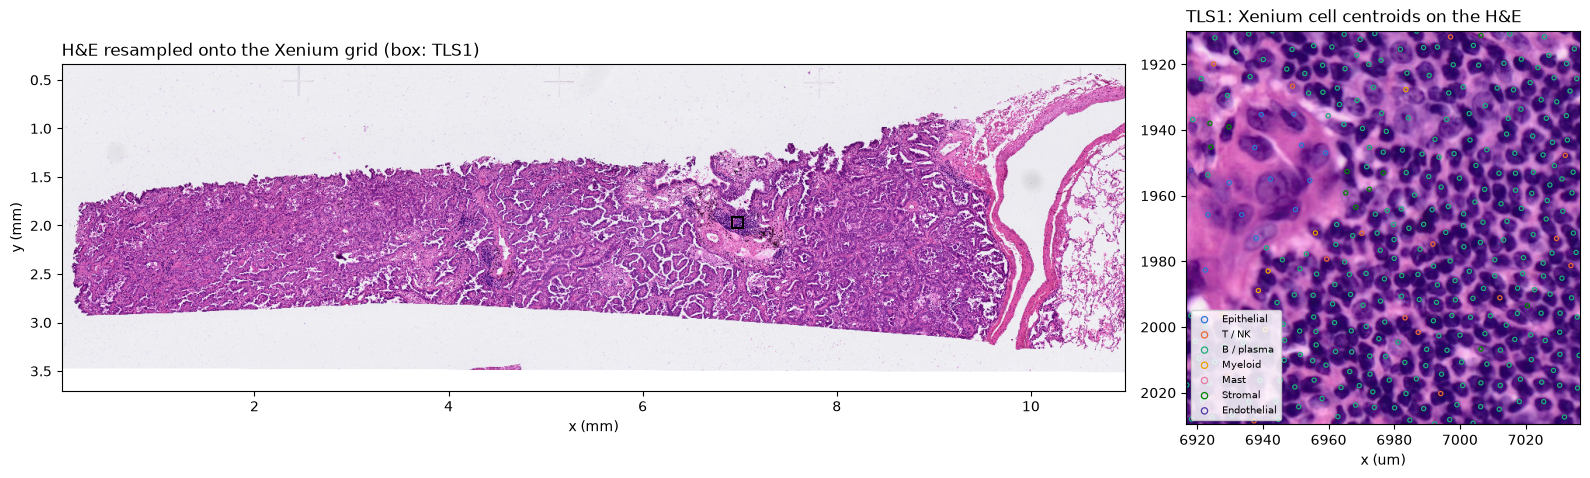

In [2]:
adata = xu.load_step("time")
xy = adata.obsm["spatial"]
cell_type = adata.obs["cell_type"].astype(str)
lineage = adata.obs["lineage"].astype(str)
LINEAGES = list(xu.LINEAGE_COLORS)
M = he.load_alignment(xu.HE_ALIGNMENT_PATH)
BOUNDS = (np.floor(xy[:, 0].min()) - 100, np.floor(xy[:, 1].min()) - 100, np.ceil(xy[:, 0].max()) + 100, np.ceil(xy[:, 1].max()) + 100)
FOV = {"cell_56um": (0.25, 0), "context_112um": (0.5, 1)}     # name: (um per pixel, H&E pyramid level), 224 px patches

images = {}
for name, (res, level) in FOV.items():
    t0 = time.time()
    images[name] = mo.aligned_he(xu.HE_PATH, M, BOUNDS, res, level)
    h, w = images[name].shape[:2]
    print(f"{name}: H&E level {level} resampled to {res} um/px on the Xenium grid: {w:,} x {h:,} px ({time.time() - t0:.0f} s)")
print(f"\n{adata.n_obs:,} high-confidence cells, {cell_type.nunique()} cell types")


def extent(img, res):
    return [BOUNDS[0] / 1000, (BOUNDS[0] + img.shape[1] * res) / 1000, (BOUNDS[1] + img.shape[0] * res) / 1000, BOUNDS[1] / 1000]


tls1 = xy[(adata.obs["tls_id"] == "TLS1").to_numpy()].mean(axis=0)
fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [2.7, 1]})
axes[0].imshow(images["context_112um"][::16, ::16], extent=extent(images["context_112um"], 0.5))
axes[0].add_patch(plt.Rectangle(((tls1[0] - 60) / 1000, (tls1[1] - 60) / 1000), 0.12, 0.12, fill=False, color="black", lw=1.5))
axes[0].set_title("H&E resampled onto the Xenium grid (box: TLS1)", loc="left"); axes[0].set_xlabel("x (mm)"); axes[0].set_ylabel("y (mm)")
half = 60
r0, c0 = int((tls1[1] - half - BOUNDS[1]) / 0.25), int((tls1[0] - half - BOUNDS[0]) / 0.25)
axes[1].imshow(images["cell_56um"][r0:r0 + 480, c0:c0 + 480], extent=[tls1[0] - half, tls1[0] + half, tls1[1] + half, tls1[1] - half])
near = np.all(np.abs(xy - tls1) < half, axis=1)
for lin in LINEAGES:
    sel = near & (lineage == lin).to_numpy()
    axes[1].scatter(xy[sel, 0], xy[sel, 1], s=9, facecolors="none", edgecolors=xu.LINEAGE_COLORS[lin], linewidths=0.9, label=lin)
axes[1].legend(fontsize=7, loc="lower left", framealpha=0.85, markerscale=1.5)
axes[1].set_title("TLS1: Xenium cell centroids on the H&E", loc="left"); axes[1].set_xlabel("x (um)")
plt.tight_layout(); plt.show()

**Interpretation.** Both images are built in under a minute (43,840 x 13,472 px at 0.25 µm/px; 21,920 x 6,736 px at 0.5 µm/px) for 139,129 high-confidence cells in 26 types. In TLS1 the Xenium centroids sit on the dark, densely packed lymphocyte nuclei, and the larger cells at the left edge carry epithelial-coloured centroids, so a patch centred on a Xenium cell is centred on that cell in the H&E. That is the precondition for everything below.

## Part B: Embed cell-centred patches

**Purpose:** turn the H&E around each cell into numeric descriptions at three scales, so later parts can test what each scale contains.

**Approach:** sample up to 1,500 cells per cell type (all cells of rarer types; `mo.balanced_sample`), so rare immune types are not swamped by the ~85,000 tumour cells. The whole section is also cut into 112 µm tiles holding at least 5 cells, for Part E. Each cell receives three 1,024-dimensional embeddings:

| Embedding | What it summarises |
|---|---|
| **112 µm, CLS token** | the whole 112 µm patch: the cell in its tissue context |
| **56 µm, CLS token** | the whole 56 µm patch: the cell and its immediate neighbours |
| **Cell, centre tokens** | the mean of the 2 x 2 patch tokens at the centre of the 56 µm patch (8 x 8 µm): the model's representation of the cell itself, informed by its surroundings through attention |

The CLS token summarises a whole patch, so it mostly describes the neighbourhood; reading the centre tokens is the standard way to obtain a single-cell representation from a vision transformer. Nothing in the model was trained on these labels.

**Expected output:** the cache status, the number of cells, cell types and tiles, the embedding sizes, and an example grid (two cells per lineage, each at 112 µm and 56 µm, centroid circled). Check that the circled cell is visible and centred.

**Note:** embedding is the one slow step (~20 min on an Apple M3 Max GPU in half precision), so it is cached in `embeddings_<model>.npz`; `RECOMPUTE = True` re-runs it and overwrites the cache. The cache is checked against the current sample and stops with an error if they differ.

Loaded cached embeddings (~/data/xenium_lung/processed/he_foundation_model/embeddings_phikon-v2.npz)
28,363 cells from 26 cell types (202-1500 per type); 1,505 tiles of 112 um
Embedding size: {'cell_56um': 1024, 'cell_56um_centre': 1024, 'context_112um': 1024, 'tiles_112um': 1024}


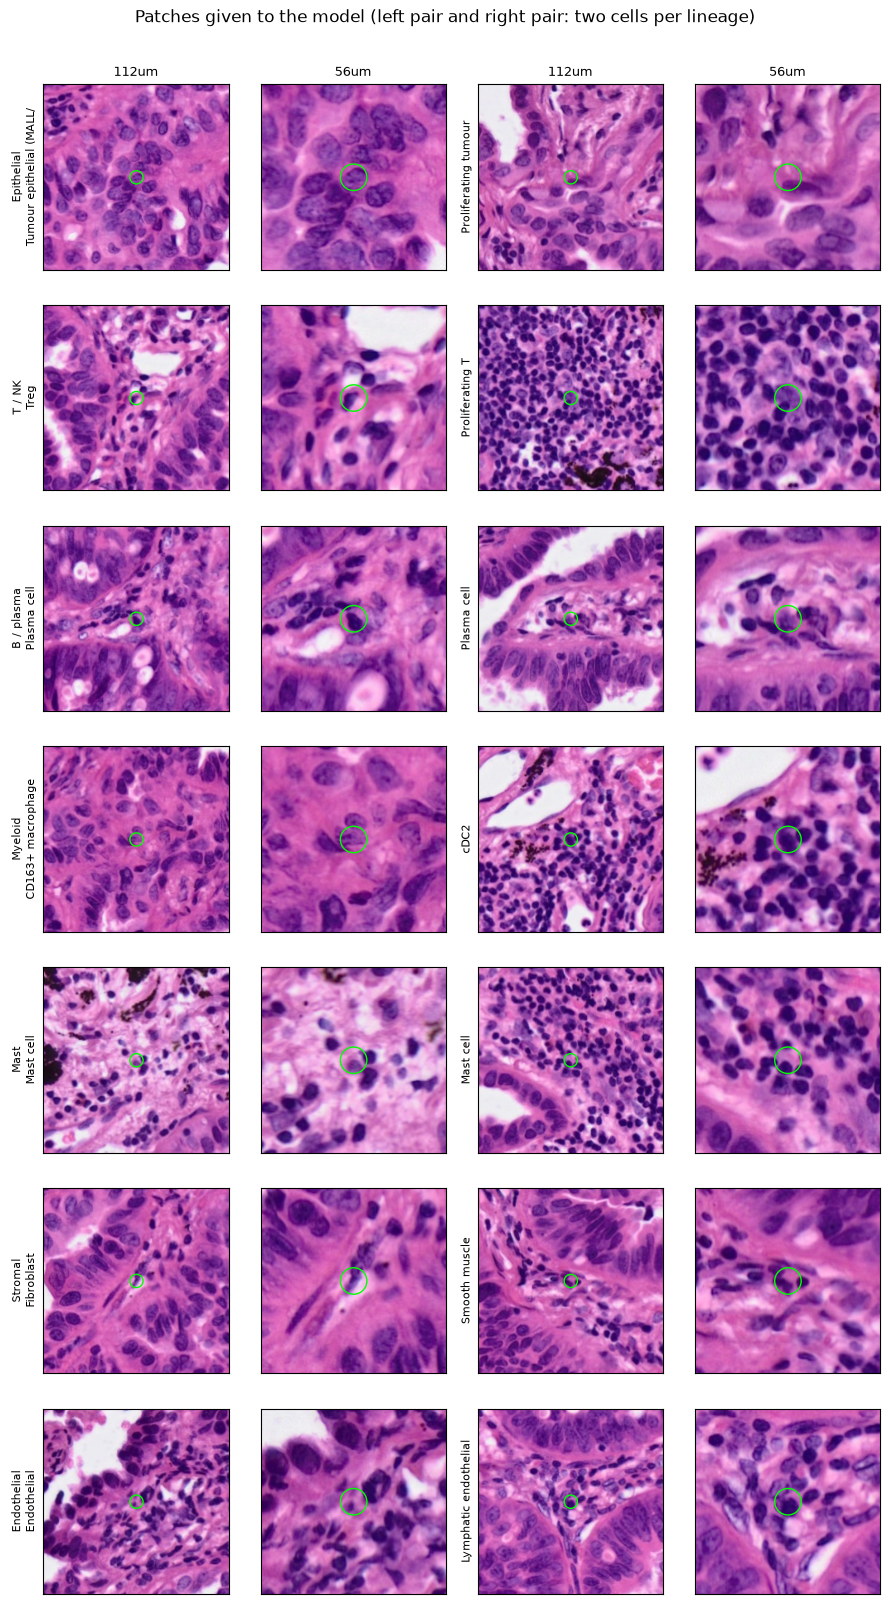

In [3]:
idx = mo.balanced_sample(cell_type, N_PER_TYPE, seed=0)
sample = adata.obs_names[idx]
xy_s, ct_s, lin_s = xy[idx], cell_type.iloc[idx].to_numpy(), lineage.iloc[idx].to_numpy()
centres, tile_of_cell = mo.tiles(xy, TILE_UM)

cache = OUT_DIR / f"embeddings_{MODEL}.npz"
if cache.exists() and not RECOMPUTE:
    z = np.load(cache)
    if not np.array_equal(z["cell_ids"], sample.to_numpy().astype(str)) or len(z["tile_centres"]) != len(centres):
        raise ValueError("The cached embeddings are for a different sample: set RECOMPUTE = True")
    emb = {k: z[k] for k in ["cell_56um", "cell_56um_centre", "context_112um", "tiles_112um"]}
    print(f"Loaded cached embeddings ({xu.display_path(cache)})")
else:
    model, device, dtype = mo.load_model(MODEL)
    emb = {}
    for name, pts, fov in [("context_112um", xy_s, "context_112um"), ("tiles_112um", centres, "context_112um"), ("cell_56um", xy_s, "cell_56um")]:
        t0, last = time.time(), [0]

        def progress(i, n):
            if i == n or time.time() - last[0] > 60:
                last[0] = time.time(); print(f"  {name}: {i:,} / {n:,} patches ({time.time() - t0:.0f} s)", flush=True)
        out = mo.embed(model, device, dtype, images[fov], pts, BOUNDS[:2], FOV[fov][0], centre=2 if name == "cell_56um" else 0, progress=progress)
        if name == "cell_56um":
            emb["cell_56um"], emb["cell_56um_centre"] = out
        else:
            emb[name] = out
    np.savez(cache, cell_ids=sample.to_numpy().astype(str), tile_centres=centres, **emb)
    print(f"Saved {xu.display_path(cache)}")

n_per = pd.Series(ct_s).value_counts()
print(f"{len(idx):,} cells from {len(n_per)} cell types ({n_per.min()}-{n_per.max()} per type); {len(centres):,} tiles of {TILE_UM} um")
print("Embedding size:", {k: v.shape[1] for k, v in emb.items()})

# Examples: two cells per lineage, each at both fields of view (circle = the cell's centroid)
rng = np.random.default_rng(3)
fig, axes = plt.subplots(len(LINEAGES), 4, figsize=(9, 2.3 * len(LINEAGES)))
for r, lin in enumerate(LINEAGES):
    for k, j in enumerate(rng.choice(np.flatnonzero(lin_s == lin), 2, replace=False)):
        for c, f in enumerate(["context_112um", "cell_56um"]):
            ax = axes[r, 2 * k + c]
            ax.imshow(mo.patches(images[f], xy_s[j:j + 1], BOUNDS[:2], FOV[f][0])[0])
            ax.add_patch(plt.Circle((112, 112), 4 / FOV[f][0], fill=False, color="lime", lw=1))
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(f.split("_")[1], fontsize=9)
            if c == 0:
                ax.set_ylabel(f"{lin}\n{ct_s[j][:24]}" if k == 0 else ct_s[j][:24], fontsize=8)
plt.suptitle("Patches given to the model (left pair and right pair: two cells per lineage)", y=1.0)
plt.tight_layout(); plt.show()

**Interpretation.** 28,363 cells from 26 cell types are embedded (202 to 1,500 per type) together with 1,505 tiles. A 56 µm patch is not a single-cell view: around a typical sampled cell it contains about 29 high-confidence cells (interquartile range 24-34), more in dense lymphoid and tumour areas. The example patches show why the CLS token mostly reflects tissue context and the centre tokens are needed to read the cell itself.

## Part C: Which cell is this? Cell types from morphology alone

### C1. Classification accuracy with controls

**Purpose:** measure how much of each cell's Xenium identity is visible in H&E, and whether the model reads the cell or its neighbourhood.

**Approach:** a standardised multinomial logistic regression with balanced class weights (`mo.cv_classify`; PCA to 128 components for the embeddings) predicts each cell's Xenium lineage and cell type. **Cross-validation is split by 1 mm tissue blocks** (5 folds over 31 blocks), so test cells come from tissue the classifier never saw. Two controls:
- **Stain colour:** mean and SD of RGB and hematoxylin / eosin per patch, at both fields of view (24 numbers): how far does colour alone go?
- **Xenium neighbours:** the lineage mix of the *other* cells within 50 µm, from the Xenium data. If H&E does no better than knowing the neighbours, it is reading context.

The best H&E features are then re-scored with a random (leaky) split to show how much neighbouring cells on both sides of the split inflate accuracy.

**Expected output:** a table of balanced accuracy (mean recall over classes), macro F1 and chance level, for every feature set at both label levels, plus the random-split rows. Compare the H&E features against both controls.

**Note:** scores are measured on the cell-type-balanced sample, not at natural cell frequencies; a cell type concentrated in a single block cannot be learned under block splitting, because its cells are all held out together.

In [4]:
blocks = dm.blocks(xy_s, BLOCK_UM, sample).to_numpy()
t0 = time.time()
stain = np.hstack([mo.stain_features(images[f], xy_s, BOUNDS[:2], FOV[f][0]) for f in FOV])
nbrs = mo.neighbourhood_composition(xy, lineage, xy_s, 50, LINEAGES)
print(f"Control features in {time.time() - t0:.0f} s; {len(np.unique(blocks))} tissue blocks of {BLOCK_UM} um")

FEATURES = {"Stain colour (H&E)": (stain, None), "H&E model, 112 um patch": (emb["context_112um"], 128),
            "H&E model, 56 um patch": (emb["cell_56um"], 128), "H&E model, cell (centre tokens)": (emb["cell_56um_centre"], 128),
            "Xenium neighbours (50 um)": (nbrs, None)}
preds, rows = {}, []
for level, y in [("lineage", lin_s), ("cell type", ct_s)]:
    for name, (X, ncomp) in FEATURES.items():
        t0 = time.time()
        preds[level, name] = p = mo.cv_classify(X, y, blocks, n_components=ncomp)
        s = mo.scores(y, p)
        rows.append({"label": level, "features": name, **s.round(3).to_dict(), "time (s)": round(time.time() - t0)})
results = pd.DataFrame(rows).set_index(["label", "features"])
best = results.loc["cell type"].drop(["Stain colour (H&E)", "Xenium neighbours (50 um)"])["balanced accuracy"].idxmax()

# How much would a random split (neighbouring cells on both sides) overstate the best H&E features?
for level, y in [("lineage", lin_s), ("cell type", ct_s)]:
    s = mo.scores(y, mo.cv_classify(FEATURES[best][0], y, None, n_components=128))
    rows.append({"label": level, "features": f"{best}: RANDOM split (leaks)", **s.round(3).to_dict(), "time (s)": 0})
results = pd.DataFrame(rows).set_index(["label", "features"]).drop(columns="time (s)")
print(f"Best H&E features for cell type: {best}")
display(results)

Control features in 24 s; 31 tissue blocks of 1000 um
Best H&E features for cell type: H&E model, cell (centre tokens)


balanced accuracy  \
label     features                                                                
lineage   Stain colour (H&E)                                              0.375   
          H&E model, 112 um patch                                         0.390   
          H&E model, 56 um patch                                          0.437   
          H&E model, cell (centre tokens)                                 0.565   
          Xenium neighbours (50 um)                                       0.448   
cell type Stain colour (H&E)                                              0.204   
          H&E model, 112 um patch                                         0.225   
          H&E model, 56 um patch                                          0.256   
          H&E model, cell (centre tokens)                                 0.339   
          Xenium neighbours (50 um)                                       0.201   
lineage   H&E model, cell (centre tokens): RANDOM split (...              0.585   
cell type H&E model, cell (centre tokens): RANDOM split (...              0.396   

                                                              macro F1  \
label     features                                                       
lineage   Stain colour (H&E)                                     0.352   
          H&E model, 112 um patch                                0.369   
          H&E model, 56 um patch                                 0.412   
          H&E model, cell (centre tokens)                        0.532   
          Xenium neighbours (50 um)                              0.428   
cell type Stain colour (H&E)                                     0.173   
          H&E model, 112 um patch                                0.201   
          H&E model, 56 um patch                                 0.232   
          H&E model, cell (centre tokens)                        0.314   
          Xenium neighbours (50 um)                              0.174   
lineage   H&E model, cell (centre tokens): RANDOM split (...     0.551   
cell type H&E model, cell (centre tokens): RANDOM split (...     0.369   

                                                              chance (balanced)  
label     features                                                               
lineage   Stain colour (H&E)                                              0.143  
          H&E model, 112 um patch                                         0.143  
          H&E model, 56 um patch                                          0.143  
          H&E model, cell (centre tokens)                                 0.143  
          Xenium neighbours (50 um)                                       0.143  
cell type Stain colour (H&E)                                              0.038  
          H&E model, 112 um patch                                         0.038  
          H&E model, 56 um patch                                          0.038  
          H&E model, cell (centre tokens)                                 0.038  
          Xenium neighbours (50 um)                                       0.038  
lineage   H&E model, cell (centre tokens): RANDOM split (...              0.143  
cell type H&E model, cell (centre tokens): RANDOM split (...              0.038

**Interpretation.** The model sees the cell, but only when it is read at the cell.
- **Patch summaries mostly read the neighbourhood.** The CLS token of a 112 µm or 56 µm patch predicts lineage at 0.39-0.44 balanced accuracy, barely above stain colour (0.38) and below the Xenium-neighbour control (0.45). For cell type they reach 0.23-0.26, slightly above both stain colour (0.20) and neighbours (0.20).
- **The centre tokens carry information about the cell itself.** Reading the model at the cell's position lifts lineage to **0.57** (chance 0.14, about 4x) and cell type to **0.34** (chance 0.04, about 9x), clearly above the neighbourhood control.
- **Block splitting matters.** A random split reports 0.59 for lineage and 0.40 for cell type: cell-type accuracy is overstated by about 6 points. Every other number here uses the block split.

### C2. Which cell types are visible, and how they are confused

**Purpose:** find which cell types morphology recognises and which it cannot, and compare morphology with the neighbourhood control type by type.

**Approach:** recall per cell type (% of cells of that type predicted correctly) for the 112 µm CLS token, the best H&E features and the Xenium-neighbour control, and a lineage confusion matrix for the best H&E features.

**Expected output:** a bar chart of recall by cell type (dotted line = chance) and a confusion heatmap (% of each Xenium lineage by predicted lineage). Look for types where morphology beats neighbours, types where neighbours win, and the main lineage confusions.

**Note:** per-type recall for rare types rests on a few hundred cells and few blocks, so small differences are not meaningful.

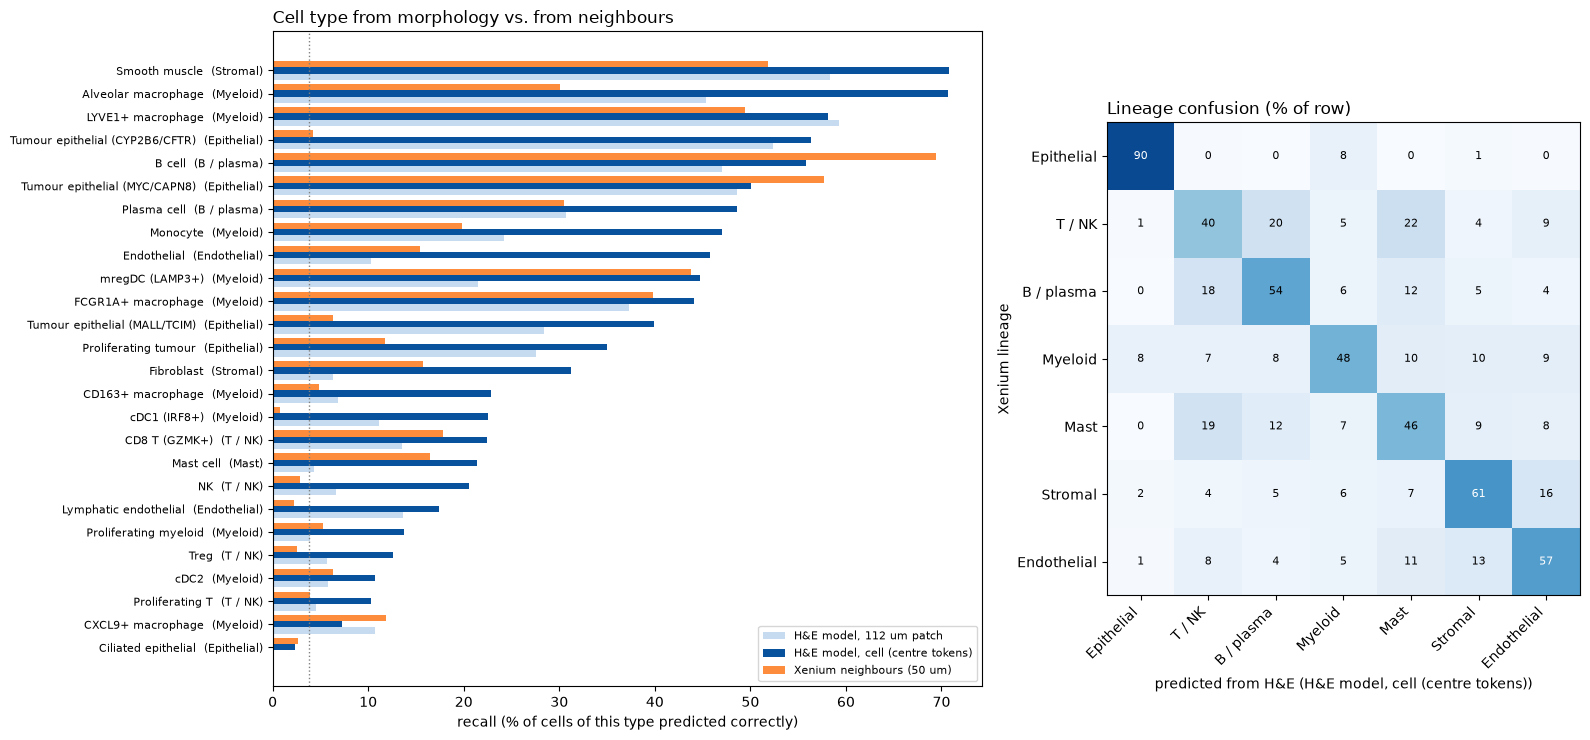

In [5]:
rec = pd.DataFrame({name: mo.recall_by_class(ct_s, preds["cell type", name]) for name in FEATURES})
rec["lineage"] = pd.Series(lin_s, index=ct_s).groupby(level=0).first()
rec = rec.sort_values(best)

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), gridspec_kw={"width_ratios": [1.5, 1]})
ypos = np.arange(len(rec))
others = [n for n in ["H&E model, 112 um patch", "H&E model, 56 um patch", "H&E model, cell (centre tokens)"] if n != best]
for k, (name, colour) in enumerate([(others[0], "#c6dbef"), (best, "#08519c"), ("Xenium neighbours (50 um)", "#fd8d3c")]):
    axes[0].barh(ypos + (k - 1) * 0.27, rec[name] * 100, height=0.27, color=colour, label=name)
axes[0].set_yticks(ypos, [f"{t}  ({lin})" for t, lin in zip(rec.index, rec["lineage"])], fontsize=8)
axes[0].axvline(100 / len(rec), color="grey", ls=":", lw=1); axes[0].set_xlabel("recall (% of cells of this type predicted correctly)")
axes[0].legend(loc="lower right", fontsize=8); axes[0].set_title("Cell type from morphology vs. from neighbours", loc="left")

cm = pd.crosstab(pd.Series(lin_s, name="Xenium lineage"), pd.Series(preds["lineage", best], name="predicted from H&E"), normalize="index")
cm = cm.reindex(index=LINEAGES, columns=LINEAGES).fillna(0) * 100
axes[1].imshow(cm, cmap="Blues", vmin=0, vmax=100)
for i in range(len(LINEAGES)):
    for j in range(len(LINEAGES)):
        axes[1].text(j, i, f"{cm.iloc[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white" if cm.iloc[i, j] > 55 else "black")
axes[1].set_xticks(range(len(LINEAGES)), LINEAGES, rotation=45, ha="right"); axes[1].set_yticks(range(len(LINEAGES)), LINEAGES)
axes[1].set_xlabel(f"predicted from H&E ({best})"); axes[1].set_ylabel("Xenium lineage"); axes[1].set_title("Lineage confusion (% of row)", loc="left")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Lineage recognition:** epithelium is recognised in 90% of cases, then stroma (61%), endothelium (57%), B / plasma (54%), myeloid (48%), mast (46%) and T / NK cells (40%).
- **Morphologically distinct cell types score highest:** smooth muscle and alveolar macrophages (about 71%; spindle-cell bundles, and large cells in air spaces), followed by LYVE1+ macrophages and the CYP2B6/CFTR and MYC/CAPN8 tumour programmes (50-58%).
- **The confusions are the ones a pathologist would make.** T / NK cells are confused with mast (22%) and B / plasma cells (20%); stroma with endothelium (16%). Small round immune cells and spindle-shaped cells are hard to tell apart in H&E.
- **Functional states are hardly visible.** Treg, CXCL9+ macrophages, proliferating T cells and cDC2 reach only 7-13% recall (chance 4%): they differ in expression, not in shape.
- **Location-defined types are better predicted by neighbours.** B cells (69% from the Xenium neighbourhood vs 56% from morphology), the MYC/CAPN8 tumour programme (58% vs 50%) and CXCL9+ macrophages (12% vs 7%) are defined by where they sit (TLS, one tumour region, immune hubs) as much as by how they look.
- **Ciliated cells are an evaluation artefact, not a morphology failure:** 97% of them lie in one 1 mm block, so block splitting holds almost all of them out of training at once and their recall is near zero.

## Part D: Which genes can be read from the H&E?

### D1. Gene predictability: own vs regional expression

**Purpose:** decide whether a gene is predictable from H&E because the model sees the expressing cell, or because the gene marks a tissue region.

**Approach:** ridge regression (`mo.cv_gene_r`, same block-split cross-validation) predicts each of the 377 genes from the embeddings, for two targets:
- the **cell's own expression** (log-normalised; sparse, with a median of about 29 genes detected per cell), from the centre tokens and from the 112 µm CLS token;
- the **regional expression**, the mean over all cells within 50 µm, from the 112 µm CLS token.

The score is the Pearson r between predicted and observed values. Step 10's Moran's I (how spatially clustered each gene is) is the reference for "marks a region".

**Expected output:** summary statistics of r for the three targets, the Spearman correlation between regional predictability and Moran's I, and the 15 genes with the highest regional r. Compare own and regional r for the same gene.

**Note:** r is computed across the cell-type-balanced sample, so genes of over-represented rare types count more than at natural frequencies; a gene detected in few cells can have r near zero simply because it is rarely non-zero.

In [6]:
t0 = time.time()
lognorm = adata.layers["lognorm"]
Y_cell = lognorm[idx].toarray() if hasattr(lognorm, "toarray") else np.asarray(lognorm[idx])
Y_region = mo.neighbourhood_mean(xy, lognorm, 50, rows=idx)
genes = pd.DataFrame({"r, own expression (cell tokens)": mo.cv_gene_r(emb["cell_56um_centre"], Y_cell, blocks),
                      "r, own expression (112 um)": mo.cv_gene_r(emb["context_112um"], Y_cell, blocks),
                      "r, regional expression (112 um)": mo.cv_gene_r(emb["context_112um"], Y_region, blocks)},
                     index=adata.var_names)
genes["detected in % of sampled cells"] = 100 * (Y_cell > 0).mean(axis=0)
moran = pd.read_csv(xu.PROCESSED_DIR / "step10_squidpy" / "moran_i.csv", index_col=0)["I"]
genes["Moran's I (Step 10)"] = moran.reindex(genes.index)
print(f"Ridge regression for {len(genes)} genes x 3 targets: {time.time() - t0:.0f} s\n")
print(genes.iloc[:, :3].describe().loc[["mean", "50%", "max"]].round(3).rename(index={"50%": "median"}).to_string())
rho = spearmanr(genes["r, regional expression (112 um)"], genes["Moran's I (Step 10)"], nan_policy="omit")[0]
print(f"\nSpearman correlation, regional predictability vs Moran's I: {rho:.2f}")
display(genes.sort_values("r, regional expression (112 um)", ascending=False).head(15).round(2))

Ridge regression for 377 genes x 3 targets: 15 s

        r, own expression (cell tokens)  r, own expression (112 um)  r, regional expression (112 um)
mean                              0.196                       0.152                            0.464
median                            0.172                       0.117                            0.518
max                               0.727                       0.678                            0.948

Spearman correlation, regional predictability vs Moran's I: 0.77


,"r, own expression (cell tokens)","r, own expression (112 um)","r, regional expression (112 um)",detected in % of sampled cells,Moran's I (Step 10)
EPCAM,0.73,0.61,0.95,31.52,0.46
CXCR4,0.56,0.51,0.95,37.12,0.36
MALL,0.71,0.61,0.93,35.81,0.53
PTPRC,0.48,0.37,0.93,41.74,0.25
CAPN8,0.71,0.55,0.92,23.72,0.45
TRAC,0.55,0.47,0.91,25.78,0.34
CYTIP,0.40,0.34,0.91,28.54,0.21
OGN,0.53,0.59,0.91,5.26,0.38
MYH11,0.73,0.68,0.91,10.83,0.45
KRT7,0.56,0.52,0.90,18.95,0.40


**Interpretation.** Own expression is hard to predict (median r 0.17 with the centre tokens, 0.12 with the 112 µm CLS token); regional expression is much easier (median r 0.52, maximum 0.95). Regional predictability follows spatial clustering (Spearman 0.77 with Moran's I). The genes predicted best regionally are lineage and region markers (EPCAM, MALL, CAPN8, MYH11, ACTA2) and immune-aggregate genes (CXCR4, PTPRC, TRAC, CYTIP, CD3E), which mark the TLS and immune-rich areas.

### D2. Immune and checkpoint genes

**Purpose:** test the genes behind the Step 9 tumour immune microenvironment findings directly, because they are the ones a clinical H&E model would most want to infer.

**Approach:** plot each gene's own-expression r against its regional r (112 µm embedding), and regional r against Moran's I, labelling checkpoint, immune and reference genes; then list their values.

**Expected output:** two scatter plots (each dot is a gene; dotted line = equal own and regional r) and a table for the labelled genes. Check where checkpoint genes fall relative to the immune and lineage genes.

**Note:** genes detected in few cells (PDCD1 in 0.2% of sampled cells) give little signal to learn from, so near-zero r partly reflects detection on the panel, not only morphology.

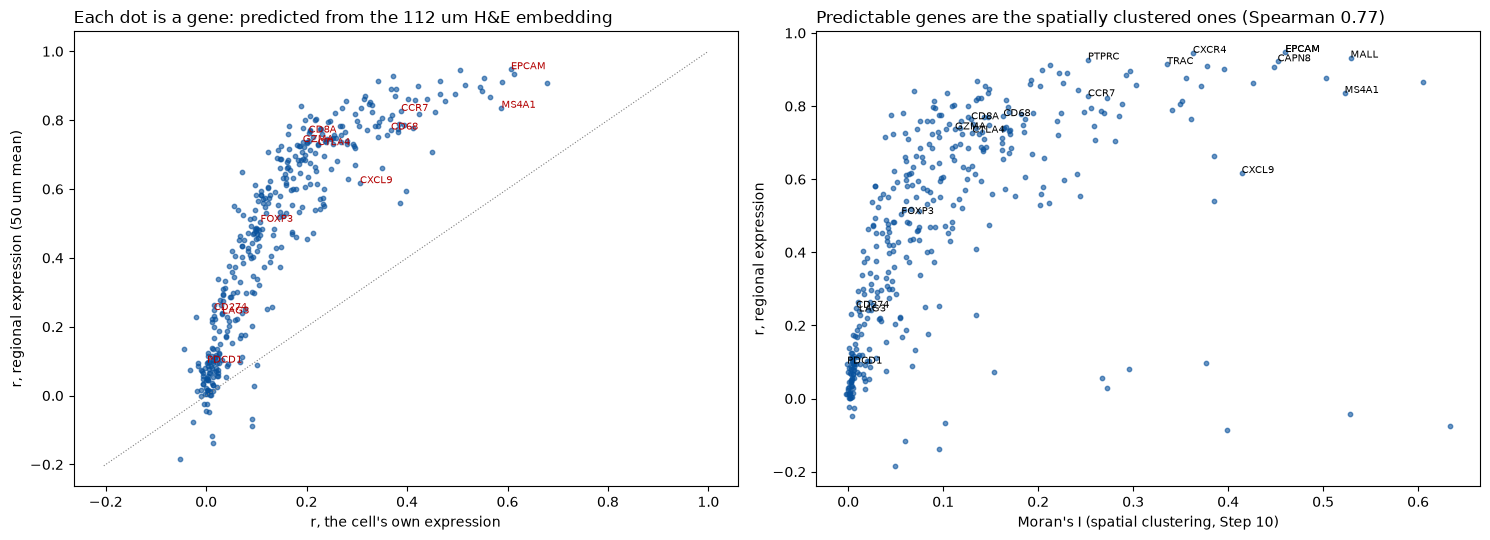

,"r, own expression (cell tokens)","r, own expression (112 um)","r, regional expression (112 um)",detected in % of sampled cells,Moran's I (Step 10)
PDCD1,0.02,0.00,0.10,0.20,-0.00
CD274,0.02,0.02,0.25,2.05,0.01
LAG3,0.04,0.03,0.24,1.81,0.01
CTLA4,0.28,0.22,0.73,8.81,0.13
FOXP3,0.16,0.11,0.50,4.40,0.06
CXCL9,0.33,0.31,0.62,9.39,0.41
CCR7,0.40,0.39,0.83,6.85,0.25
GZMA,0.29,0.19,0.74,8.35,0.11
CD8A,0.27,0.20,0.76,7.24,0.13
MS4A1,0.60,0.59,0.84,8.12,0.52


In [7]:
CHECK = ["PDCD1", "CD274", "LAG3", "CTLA4", "FOXP3", "CXCL9", "CCR7", "GZMA", "CD8A", "MS4A1", "CD68", "EPCAM"]
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.scatter(genes["r, own expression (112 um)"], genes["r, regional expression (112 um)"], s=10, color="#08519c", alpha=0.6)
lim = [min(0, genes.iloc[:, :3].min().min()) - 0.02, genes.iloc[:, :3].max().max() + 0.05]
ax.plot(lim, lim, color="grey", lw=0.8, ls=":")
for g in CHECK:
    if g in genes.index:
        ax.annotate(g, (genes.loc[g, "r, own expression (112 um)"], genes.loc[g, "r, regional expression (112 um)"]), fontsize=7, color="#b30000")
ax.set_xlabel("r, the cell's own expression"); ax.set_ylabel("r, regional expression (50 um mean)")
ax.set_title("Each dot is a gene: predicted from the 112 um H&E embedding", loc="left")
ax = axes[1]
ax.scatter(genes["Moran's I (Step 10)"], genes["r, regional expression (112 um)"], s=10, color="#08519c", alpha=0.6)
for g in genes.nlargest(6, "r, regional expression (112 um)").index.tolist() + [g for g in CHECK if g in genes.index]:
    ax.annotate(g, (genes.loc[g, "Moran's I (Step 10)"], genes.loc[g, "r, regional expression (112 um)"]), fontsize=7)
ax.set_xlabel("Moran's I (spatial clustering, Step 10)"); ax.set_ylabel("r, regional expression")
ax.set_title(f"Predictable genes are the spatially clustered ones (Spearman {rho:.2f})", loc="left")
plt.tight_layout(); plt.show()
display(genes.loc[[g for g in CHECK if g in genes.index]].round(2))

**Interpretation.** H&E predicts where a gene is expressed, not which cell expresses it.
- **Lineage markers with distinct morphology** are predicted best per cell: EPCAM, MALL, CAPN8 and MYH11 (r 0.71-0.73 with the centre tokens).
- **Immune genes show the gap most clearly.** CCR7, CD8A, GZMA and CTLA4 are predicted well regionally (r 0.73-0.83) but poorly per cell (0.27-0.40): the H&E finds the immune neighbourhoods, not the individual T cells.
- **Checkpoint genes are barely visible.** PDCD1, CD274 and LAG3 have r ≤ 0.04 per cell and 0.10-0.25 regionally. The PD-L1 and PD-1 findings of Step 9 could not have been made from the H&E.
- **A few spatially clustered genes are not predictable at all** (Moran's I 0.27-0.63, regional r near 0): the ciliated-cell genes (C20orf85, C1orf194, TSPAN19, SNTN) and CXCL10. Their expression is concentrated in one area, so block splitting holds it out of training, the same artefact as ciliated cells in C2.

This is the main caveat for models that predict expression from H&E: a high gene-level correlation often reflects that the gene marks a region, which a much simpler model of tissue architecture would also capture.

## Part E: Morphology domains from the H&E alone

### E1. Clustering H&E tiles

**Purpose:** test whether morphology alone recovers the tissue regions found from expression in notebook 04.

**Approach:** standardise the 1,505 tile embeddings (112 µm tiles with at least 5 cells), reduce them to 50 principal components and cluster with k-means for K = 4-12. **No Xenium data is used** to make these domains. Each K is compared by ARI with the tile-majority BANKSY and CellCharter domains and the tile-majority lineage. K = 7, CellCharter's most stable K, is kept and named by its lineage composition (`dm.name_domains`).

**Expected output:** an ARI table across K, and the lineage composition and tile count of each morphology domain. Check whether agreement depends strongly on K.

**Note:** tiles are compared by their majority domain, which hides mixed tiles; the same K is used for comparability with CellCharter, not because it is optimal for morphology.

In [8]:
Z = PCA(50, random_state=0).fit_transform(StandardScaler().fit_transform(emb["tiles_112um"]))
domains = pd.read_csv(xu.PROCESSED_DIR / "spatial_domains" / "domains.csv.gz", index_col="cell_id")
cell_ids = adata.obs["cell_id"].astype(str).to_numpy() if "cell_id" in adata.obs else adata.obs_names.to_numpy()
tile_maj = {m: mo.majority(domains[m].reindex(cell_ids).fillna("none").reset_index(drop=True), tile_of_cell, len(centres))
            for m in ["banksy", "cellcharter"]}
tile_maj["lineage"] = mo.majority(lineage.reset_index(drop=True), tile_of_cell, len(centres))

sens = []
for k in range(4, 13):
    lab = KMeans(k, n_init=10, random_state=0).fit_predict(Z)
    sens.append({"K": k, **{f"ARI vs {m}": ari(tile_maj[m], lab) for m in ["banksy", "cellcharter", "lineage"]}})
    if k == 7:
        morph = lab
display(pd.DataFrame(sens).set_index("K").round(3).T)

cell_morph = pd.Series(np.where(tile_of_cell >= 0, morph[np.maximum(tile_of_cell, 0)], -1), index=adata.obs_names)
in_tile = cell_morph >= 0
named = dm.name_domains(cell_morph[in_tile].astype(str), lineage[in_tile], LINEAGES)
names = dict(zip(cell_morph[in_tile].to_numpy(), named.to_numpy()))
tile_names = pd.Series([names[k] for k in morph])
comp = pd.crosstab(named, lineage[in_tile], normalize="index").reindex(columns=LINEAGES).fillna(0) * 100
comp["tiles"] = tile_names.value_counts()
display(comp.round(0))

K,4,5,6,7,8,9,10,11,12
ARI vs banksy,0.240,0.238,0.267,0.301,0.285,0.258,0.245,0.254,0.252
ARI vs cellcharter,0.255,0.253,0.217,0.212,0.198,0.179,0.165,0.169,0.158
ARI vs lineage,0.145,0.154,0.181,0.159,0.143,0.117,0.115,0.103,0.086


lineage,Epithelial,T / NK,B / plasma,Myeloid,Mast,Stromal,Endothelial,tiles
row_0,,,,,,,,
D1: Epithelial 83%,83.0,1.0,0.0,11.0,0.0,3.0,2.0,247
D2: Epithelial 76%,76.0,1.0,2.0,4.0,1.0,11.0,5.0,189
D3: Epithelial 76%,76.0,2.0,2.0,7.0,1.0,9.0,3.0,138
D4: Epithelial 70%,70.0,3.0,3.0,7.0,1.0,11.0,5.0,429
D5: Epithelial 32% + Stromal 20%,32.0,12.0,12.0,10.0,4.0,20.0,9.0,269
D6: Stromal 53% + Endothelial 19%,5.0,5.0,4.0,11.0,3.0,53.0,19.0,166
D7: Endothelial 65%,1.0,7.0,0.0,10.0,2.0,14.0,65.0,67


**Interpretation.** Agreement does not hinge on K: ARI with BANKSY stays between 0.24 and 0.30 (highest at K = 7), with CellCharter between 0.16 and 0.26 (falling as K grows), and with the tile-majority lineage between 0.09 and 0.18. At K = 7 the domains are four epithelial domains (70-83% epithelial; D1 also 11% myeloid), a mixed interface domain (D5: 32% epithelial, 20% stromal, 12% T / NK, 12% B / plasma), stroma (D6) and an endothelium-rich domain (D7, 65%).

### E2. Morphology domains on the tissue

**Purpose:** compare the morphology domains with the expression domains where they are, not only by a single ARI.

**Approach:** draw the K = 7 morphology domains and the tile-majority CellCharter domains (notebook 04) on tile coordinates, and report ARI with CellCharter and BANKSY.

**Expected output:** two tile maps and the two ARI values. Compare the stroma at the right-hand edge, the tumour regions and the lymphoid areas.

**Note:** colours are assigned per map, so the same colour does not mean the same domain in both panels.

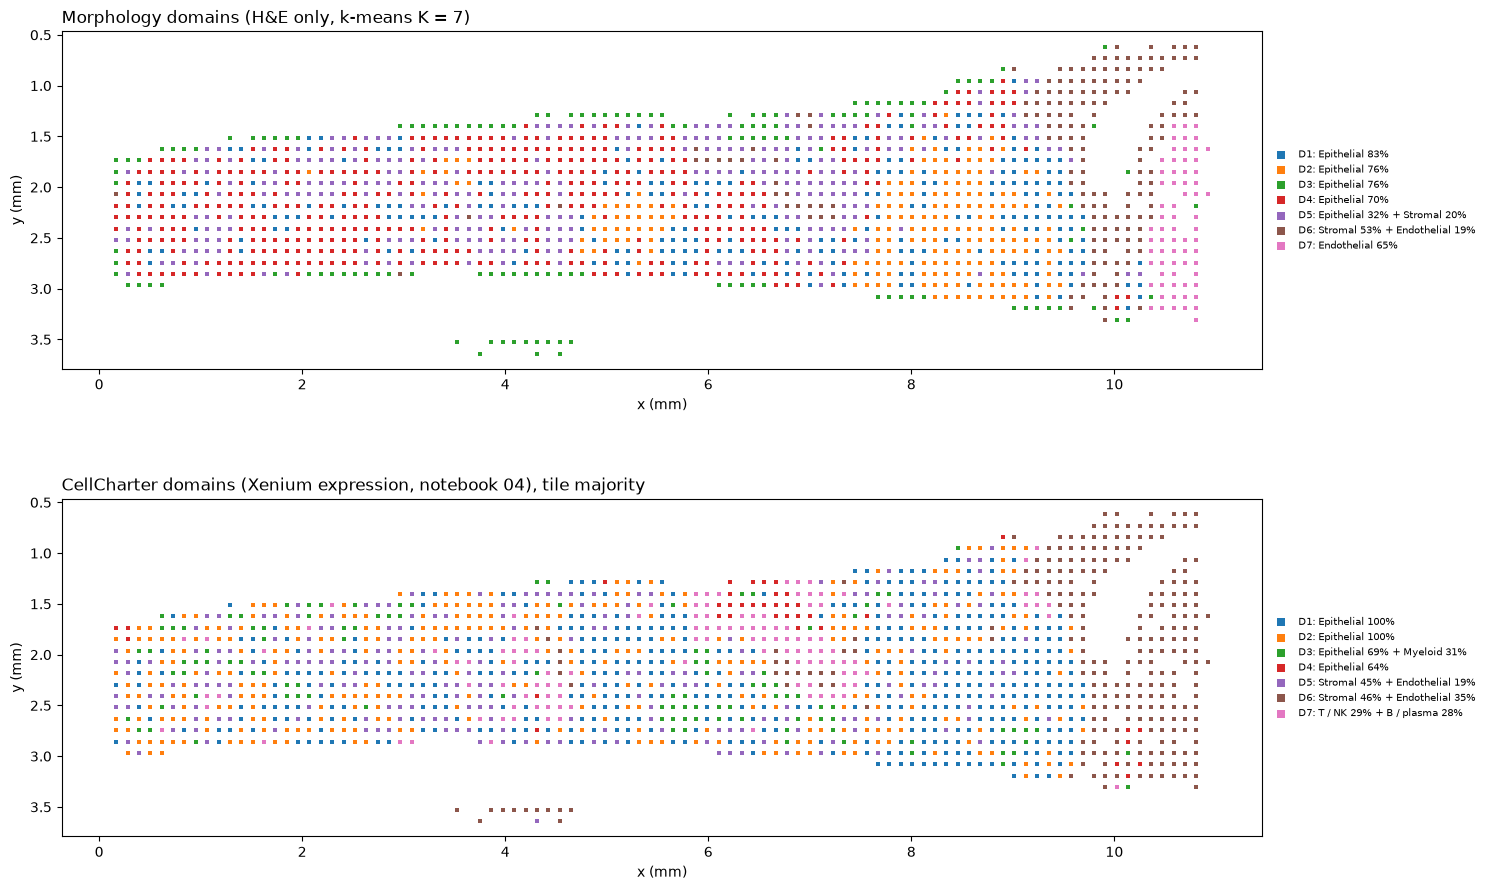

ARI, morphology (K = 7) vs CellCharter: 0.21; vs BANKSY: 0.30


In [9]:
order = sorted(tile_names.unique(), key=lambda s: int(s.split(":")[0].lstrip("D")))
cc_order = sorted(tile_maj["cellcharter"].unique(), key=lambda s: int(s.split(":")[0].lstrip("D")) if s[0] == "D" else 99)
fig, axes = plt.subplots(2, 1, figsize=(15, 9.5))
for ax, labels, lev, title in [(axes[0], tile_names, order, "Morphology domains (H&E only, k-means K = 7)"),
                               (axes[1], tile_maj["cellcharter"], cc_order, "CellCharter domains (Xenium expression, notebook 04), tile majority")]:
    cmap = plt.get_cmap("tab10")
    for i, d in enumerate(lev):
        sel = (labels == d).to_numpy()
        ax.scatter(centres[sel, 0] / 1000, centres[sel, 1] / 1000, s=9, marker="s", color=cmap(i % 10), label=d, linewidths=0)
    ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_title(title, loc="left"); ax.set_xlabel("x (mm)"); ax.set_ylabel("y (mm)")
    ax.legend(markerscale=2, fontsize=7, loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
plt.tight_layout(); plt.show()
print(f"ARI, morphology (K = 7) vs CellCharter: {ari(tile_maj['cellcharter'], morph):.2f}; vs BANKSY: {ari(tile_maj['banksy'], morph):.2f}")

**Interpretation.** Morphology alone recovers the coarse tissue layout (ARI 0.21 with CellCharter, 0.30 with BANKSY).
- **Stroma and vessels match well:** the stromal and endothelial morphology domains (D6, D7) occupy the right-hand edge (x > 9.5 mm), where CellCharter's stromal-endothelial domain lies; 214 of its 251 tiles fall in D6 or D7.
- **The tumour-myeloid zone has a morphological counterpart:** most tiles of CellCharter's epithelial-myeloid domain fall in morphology D1 (75 of 109), the epithelial domain with 11% myeloid cells.
- **Lymphoid areas have no domain of their own:** 89 of 118 tiles of CellCharter's lymphoid domain fall in the mixed interface domain D5.
- **One artefact to note:** D3 lines the tissue border and the detached sliver at the bottom; partly empty tiles group together by their white background, not their tissue.

## Part F: Export

**Purpose:** save the embeddings, predictions and domains so later analyses and Xenium Explorer can use them without re-running the model.

**Approach:**
- `he_embeddings_<model>.h5ad`: the sampled cells with labels, block, out-of-fold predictions (H&E lineage and cell type, neighbour-based cell type), coordinates, and the three embeddings in `obsm` (float16);
- `classification_scores.csv`, `gene_predictability.csv` and `morphology_domains_tiles.csv`;
- `xenium_explorer/morphology_domains.csv`: every high-confidence cell inside a tile with its morphology domain, as a Xenium Explorer cell group (`cell_id,group,color`, same colours as the map).

**Expected output:** the list of saved files and their sizes (the embedding cache is not listed).

**Note:** overwrites these files on each run. Cells outside the 1,505 tiles have no morphology domain and are absent from the cell-group file.

In [10]:
out = ad.AnnData(obs=pd.DataFrame({"cell_type": ct_s, "lineage": lin_s, "block": blocks,
                                   "pred_lineage_he": preds["lineage", best], "pred_cell_type_he": preds["cell type", best],
                                   "pred_cell_type_neighbours": preds["cell type", "Xenium neighbours (50 um)"]}, index=sample.astype(str)))
out.obsm["spatial"] = xy_s.astype(np.float32)
for k in ["cell_56um", "cell_56um_centre", "context_112um"]:
    out.obsm[f"X_{MODEL}_{k}"] = emb[k].astype(np.float16)
out.uns["he_foundation_model"] = {"model": MODEL, "repo": mo.MODELS[MODEL]["repo"], "n_per_type": N_PER_TYPE, "block_um": BLOCK_UM, "prediction_features": best}
out.write_h5ad(OUT_DIR / f"he_embeddings_{MODEL}.h5ad", compression="gzip")
results.to_csv(OUT_DIR / "classification_scores.csv")
genes.to_csv(OUT_DIR / "gene_predictability.csv")
pd.DataFrame({"x_um": centres[:, 0], "y_um": centres[:, 1], "morphology_domain": tile_names,
              "cellcharter": tile_maj["cellcharter"], "banksy": tile_maj["banksy"]}).to_csv(OUT_DIR / "morphology_domains_tiles.csv", index=False)

palette = {d: to_hex(plt.get_cmap("tab10")(i % 10)) for i, d in enumerate(order)}   # same colours as the map above
groups = pd.DataFrame({"cell_id": cell_ids[in_tile.to_numpy()], "group": named.to_numpy()})
groups["color"] = groups["group"].map(palette)
(OUT_DIR / "xenium_explorer").mkdir(exist_ok=True)
groups.to_csv(OUT_DIR / "xenium_explorer" / "morphology_domains.csv", index=False)
for f in sorted(OUT_DIR.rglob("*")):
    if f.is_file() and not f.name.startswith("embeddings_"):
        print(f"  {xu.display_path(f)}  ({f.stat().st_size / 1e6:.1f} MB)")

  ~/data/xenium_lung/processed/he_foundation_model/classification_scores.csv  (0.0 MB)
  ~/data/xenium_lung/processed/he_foundation_model/gene_predictability.csv  (0.0 MB)
  ~/data/xenium_lung/processed/he_foundation_model/he_embeddings_phikon-v2.h5ad  (162.7 MB)
  ~/data/xenium_lung/processed/he_foundation_model/morphology_domains_tiles.csv  (0.1 MB)
  ~/data/xenium_lung/processed/he_foundation_model/xenium_explorer/morphology_domains.csv  (5.8 MB)


**Interpretation.** Five files are written, the largest being the 163 MB embedding file; the cell-group file loads into Xenium Explorer to view the morphology domains over the H&E.

## Conclusions

1. **A pathology foundation model does see single cells, if it is read at the cell.** Whole-patch embeddings (CLS token) mostly encode the neighbourhood and do little better than stain colour or knowing the Xenium neighbours; the model's tokens at the cell's position predict lineage at 0.57 and cell type at 0.34 balanced accuracy (about 4x and 9x chance) on held-out tissue blocks.
2. **Morphology resolves lineages and distinctive cell types, not functional states.** Epithelium (90%), smooth muscle and alveolar macrophages (about 71%) are recognised; Tregs, CXCL9+ macrophages, proliferating T cells and dendritic-cell subsets are not. Lymphocytes and mast cells are confused with each other, as in routine pathology.
3. **H&E predicts regional expression, not single-cell expression.** Gene predictability follows spatial clustering (Moran's I, Spearman 0.77); immune genes are predicted well per region but poorly per cell, and checkpoint genes (PD-1, PD-L1, LAG-3) are barely visible. The molecular TIME findings of Steps 7-9 need the spatial transcriptomics.
4. **Evaluation design changes the answer.** A random split overstates cell-type accuracy by about 6 points; without balanced class weights the classifier was pulled towards myeloid cells, the lineage with the most cell types (10) and therefore the most cells in the balanced sample; and a cell type confined to one block (ciliated cells) cannot be evaluated under block splitting. Block-split cross-validation, a colour baseline and a neighbourhood control are what make these numbers interpretable.
5. **Morphology domains capture the coarse layout** (ARI 0.30 with BANKSY, 0.21 with CellCharter): stroma, vessels and a tumour-myeloid zone match; lymphoid areas merge into a mixed interface domain; partly empty tiles at the tissue border cluster together, an artefact to mask in a production pipeline.
6. **Limits:** one section and one model; accuracies are measured on a cell-type-balanced sample, not at natural frequencies; Xenium labels carry their own segmentation noise (mixed cells were excluded); the H&E is a separate scan with a few µm of residual misalignment, which lowers single-cell scores. Gated models (UNI2, Virchow2) or fine-tuning on these labels would be the next step.

The embeddings (`he_embeddings_phikon-v2.h5ad`) and the morphology-domain cell groups for Xenium Explorer are in the output folder.